# Chapter 4: Characteristic Classes

**Source Span.** Bott--Tu, *Differential Forms in Algebraic Topology*, Chapter IV, printed pages `266-286` / PDF page labels `266-286`. I used the extracted source span for chapter structure and terminology: Section 20 builds Chern classes from projectivization, Section 21 proves and uses the splitting principle through flag bundles, and Section 22 begins the real-bundle passage to Pontrjagin classes through conjugation and complexification.

**Chapter Goal.** Turn characteristic classes from names into inspectable data. A vector bundle is hard to draw globally, so this notebook draws and computes with the devices the chapter uses: tautological bundles over projectivizations, the Leray-Hirsch relation defining Chern classes, flag-bundle splitting, symmetric polynomials in formal Chern roots, and the paired-root cancellation behind Pontrjagin classes.

The notebook is standalone. It does not reproduce textbook prose, exercises, page images, or figures. Every artifact is generated from the code cells below and saved under `artifacts/chapter-04-characteristic-classes/`.


## Computational Translation Guide

The source span uses smooth vector bundles and de Rham cohomology. In this notebook the same objects are represented in a deliberately small computational grammar.

| Source object | Computational representation | Inspection target |
| --- | --- | --- |
| A complex line bundle `L` | a formal root `x = c_1(L)` | tensoring adds roots; dualizing negates roots |
| A rank `n` complex bundle `E` | formal roots `x_1, ..., x_n` after pullback to a split manifold | `c_i(E)` are elementary symmetric polynomials |
| Projectivization `P(E)` | a relation in `H^*(M)[x]` | `x^n + c_1 x^{n-1} + ... + c_n = 0` |
| Flag/split bundle `F(E)` | a tower of projectivized quotients | polynomial identities can be checked on line bundles, then descended |
| A real bundle `V` | its complexification `V_C` | conjugate root pairs force odd Chern classes to cancel |
| Euler and Stiefel-Whitney context | a family table, not a de Rham computation of mod-2 classes | Euler needs orientation; Stiefel-Whitney lives over mod-2 coefficients; Pontrjagin lives in even real degrees |

The central proof move is the **splitting principle**: pull back far enough that the bundle becomes a direct sum of line bundles, prove a symmetric polynomial identity there, then use injectivity of pullback on cohomology to return to the original base.


## Visual Storyboard

1. **Characteristic-class route graph.** Shows how the chapter moves from Euler/Stiefel-Whitney context to Chern classes, splitting, and Pontrjagin classes. The learner should inspect which nodes are definitions, which are proof devices, and which are computed consequences.
2. **Projectivization relation diagram.** Displays the tautological exact sequence over `P(E)` and the single polynomial relation that defines the Chern classes of `E`.
3. **Splitting-principle flag tower.** Turns the proof technique into a visible sequence of projectivizations, ending with formal Chern roots and an injective pullback.
4. **Symbolic Chern-root checks.** Uses SymPy to verify Whitney product, dual bundle signs, tensoring by a line bundle, exterior square behavior, and the projectivization relation.
5. **Pontrjagin paired-root bridge.** Draws and checks why complexification of a real bundle produces conjugate pairs and why the odd Chern classes vanish in de Rham cohomology.
6. **Applied lab.** Uses a Plotly root-coefficient explorer: move one formal line-bundle root and watch Chern coefficients change, including the top-class failure when one root is zero.


In [1]:
from pathlib import Path
import itertools
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display
from PIL import Image, ImageStat

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Forms in Algebraic Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-04-characteristic-classes"
UNIT_TITLE = "Characteristic Classes"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 13,
})

source_span = {
    "book": "Bott-Tu, Differential Forms in Algebraic Topology",
    "chapter": "Chapter IV: Characteristic Classes",
    "printed_pages": "266-286",
    "pdf_page_labels": "266-286",
    "sections_read": [
        "Chapter IV introduction",
        "Section 20: Chern Classes of a Complex Vector Bundle",
        "Section 21: The Splitting Principle and Flag Manifolds",
        "Section 22 opening: Pontrjagin Classes",
    ],
    "source_use": "Structure, terminology, theorem orientation, and concept coverage only",
}
source_span_path = save_json(source_span, CHECKS / "source-span.json")
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Differential-Forms-in-Algebraic-Topology
Artifact root: artifacts\chapter-04-characteristic-classes


## Library Routing

Characteristic classes are partly visual and partly algebraic. The diagrams should expose bundle constructions; the exact checks should expose the polynomial identities that make the constructions useful.


In [2]:
routing_rows = [
    {
        "concept": "chapter route and proof dependencies",
        "representation": "directed graph with typed nodes",
        "library": "NetworkX + Matplotlib",
        "why": "the chapter is organized by dependencies between definitions, constructions, and proof moves",
        "artifact": "figures/characteristic-class-route.png",
        "check": "graph is weakly connected and contains the source sections",
    },
    {
        "concept": "projectivization and tautological sequence",
        "representation": "labeled bundle diagram",
        "library": "Matplotlib",
        "why": "a static exact-sequence diagram is clearer than a 3D rendering for this algebraic construction",
        "artifact": "figures/chern-projectivization-relation.png",
        "check": "rank n relation has n+1 terms and Leray-Hirsch basis length n",
    },
    {
        "concept": "splitting principle and flag bundle",
        "representation": "tower diagram plus basis count",
        "library": "Matplotlib + SymPy",
        "why": "the proof is a sequence of projectivizations whose algebra is a finite monomial basis",
        "artifact": "figures/splitting-principle-flag-tower.png",
        "check": "rank 4 flag basis count equals 4!",
    },
    {
        "concept": "Chern-root polynomial identities",
        "representation": "exact symbolic identities and CSV ledger",
        "library": "SymPy + pandas",
        "why": "formal roots reduce Whitney, dual, tensor, exterior, and top-class identities to exact polynomial checks",
        "artifact": "checks/symbolic-polynomial-checks.json",
        "check": "all symbolic residuals simplify to zero",
    },
    {
        "concept": "Pontrjagin classes from complexification",
        "representation": "paired-root cancellation diagram",
        "library": "SymPy + Matplotlib",
        "why": "conjugate pairs are the visible reason odd Chern classes vanish for real bundles in de Rham cohomology",
        "artifact": "figures/pontrjagin-complexification-roots.png",
        "check": "c1 and c3 of a rank 4 real complexification vanish symbolically",
    },
    {
        "concept": "applied Chern-root lab",
        "representation": "interactive coefficient plot",
        "library": "Plotly",
        "why": "moving a root is the cleanest way to see stable symmetric coefficients and top-class failure modes",
        "artifact": "html/chern-root-polynomial-lab.html",
        "check": "top Chern coefficient is zero exactly at the displayed zero root sample",
    },
]
routing_path = save_csv(routing_rows, TABLES / "characteristic-classes-routing.csv")
display(pd.DataFrame(routing_rows))


,concept,representation,library,why,artifact,check
0,chapter route and proof dependencies,directed graph with typed nodes,NetworkX + Matplotlib,the chapter is organized by dependencies betwe...,figures/characteristic-class-route.png,graph is weakly connected and contains the sou...
1,projectivization and tautological sequence,labeled bundle diagram,Matplotlib,a static exact-sequence diagram is clearer tha...,figures/chern-projectivization-relation.png,rank n relation has n+1 terms and Leray-Hirsch...
2,splitting principle and flag bundle,tower diagram plus basis count,Matplotlib + SymPy,the proof is a sequence of projectivizations w...,figures/splitting-principle-flag-tower.png,rank 4 flag basis count equals 4!
3,Chern-root polynomial identities,exact symbolic identities and CSV ledger,SymPy + pandas,"formal roots reduce Whitney, dual, tensor, ext...",checks/symbolic-polynomial-checks.json,all symbolic residuals simplify to zero
4,Pontrjagin classes from complexification,paired-root cancellation diagram,SymPy + Matplotlib,conjugate pairs are the visible reason odd Che...,figures/pontrjagin-complexification-roots.png,c1 and c3 of a rank 4 real complexification va...
5,applied Chern-root lab,interactive coefficient plot,Plotly,moving a root is the cleanest way to see stabl...,html/chern-root-polynomial-lab.html,top Chern coefficient is zero exactly at the d...


## Route Graph: What The Chapter Is Doing

The introduction places Chern classes next to Euler, Stiefel-Whitney, and Pontrjagin classes. The source span then spends its available pages on the complex side: define Chern classes through `P(E)`, prove identities through splitting, and begin the real side by complexifying a real bundle. The graph below is a reading map for that movement.


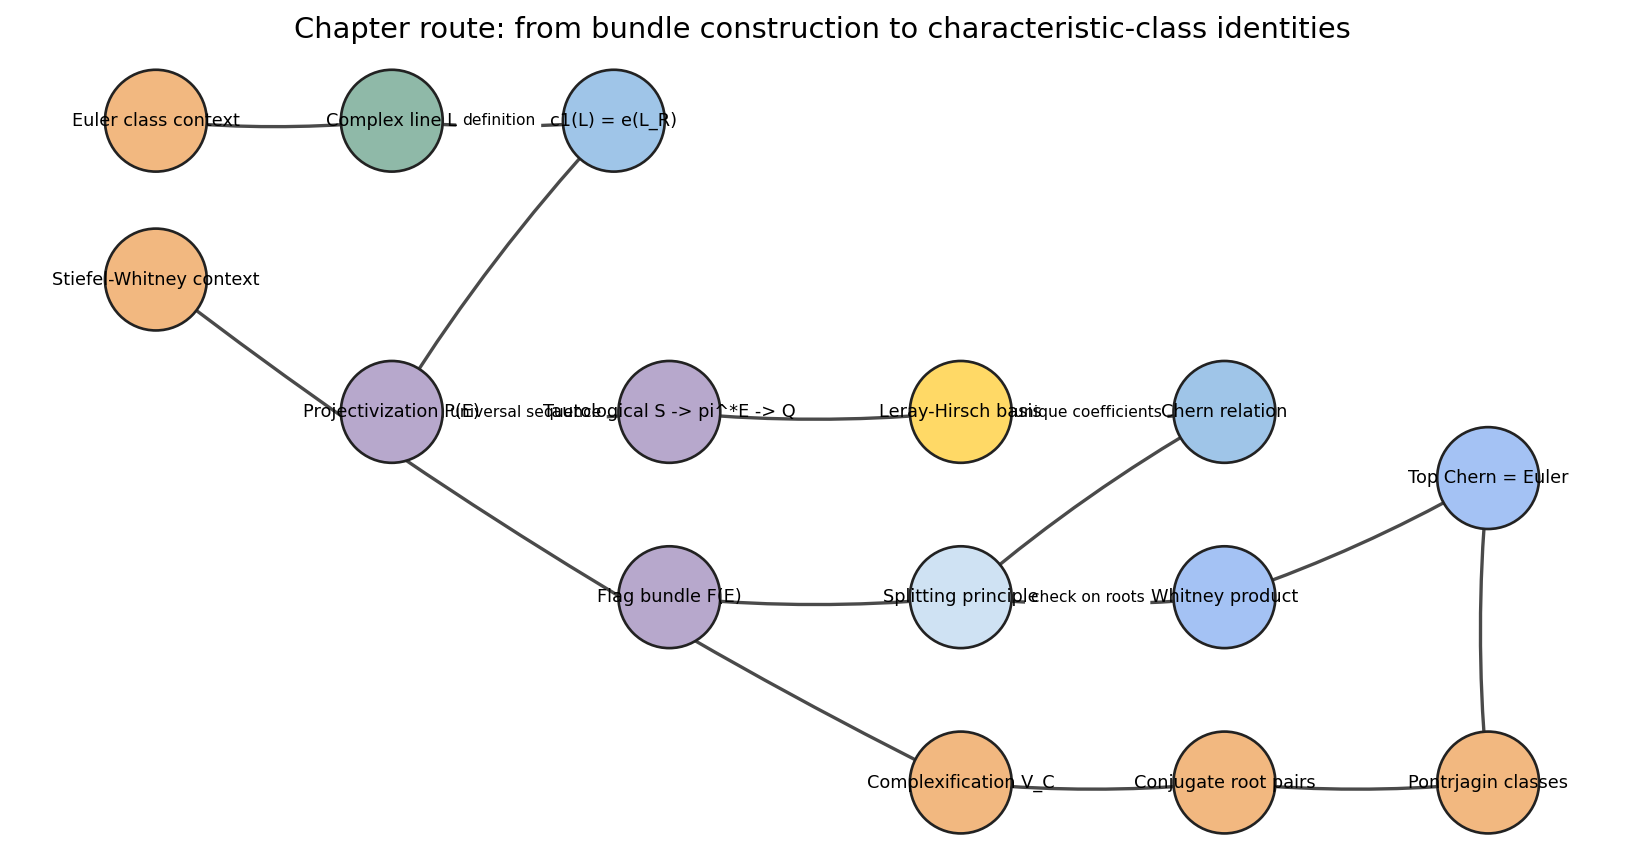

In [3]:
route_nodes = {
    "Euler class context": (0.0, 2.4, "real"),
    "Stiefel-Whitney context": (0.0, 1.2, "real"),
    "Complex line L": (1.7, 2.4, "complex"),
    "c1(L) = e(L_R)": (3.3, 2.4, "definition"),
    "Projectivization P(E)": (1.7, 0.2, "construction"),
    "Tautological S -> pi^*E -> Q": (3.7, 0.2, "construction"),
    "Leray-Hirsch basis": (5.8, 0.2, "theorem"),
    "Chern relation": (7.7, 0.2, "definition"),
    "Flag bundle F(E)": (3.7, -1.2, "construction"),
    "Splitting principle": (5.8, -1.2, "proof"),
    "Whitney product": (7.7, -1.2, "identity"),
    "Top Chern = Euler": (9.6, -0.3, "identity"),
    "Complexification V_C": (5.8, -2.6, "real"),
    "Conjugate root pairs": (7.7, -2.6, "real"),
    "Pontrjagin classes": (9.6, -2.6, "real"),
}
route_edges = [
    ("Euler class context", "Complex line L", "line bundles as oriented real 2-plane bundles"),
    ("Complex line L", "c1(L) = e(L_R)", "definition"),
    ("c1(L) = e(L_R)", "Projectivization P(E)", "line-class seed"),
    ("Projectivization P(E)", "Tautological S -> pi^*E -> Q", "universal sequence"),
    ("Tautological S -> pi^*E -> Q", "Leray-Hirsch basis", "fiber generators"),
    ("Leray-Hirsch basis", "Chern relation", "unique coefficients"),
    ("Chern relation", "Splitting principle", "polynomial data"),
    ("Flag bundle F(E)", "Splitting principle", "pull back to line sums"),
    ("Splitting principle", "Whitney product", "check on roots"),
    ("Whitney product", "Top Chern = Euler", "line-bundle product"),
    ("Stiefel-Whitney context", "Complexification V_C", "real characteristic-class neighbor"),
    ("Complexification V_C", "Conjugate root pairs", "roots plus negatives"),
    ("Conjugate root pairs", "Pontrjagin classes", "even Chern data survives"),
    ("Top Chern = Euler", "Pontrjagin classes", "real oriented comparison"),
]

G = nx.DiGraph()
for node, (x0, y0, kind) in route_nodes.items():
    G.add_node(node, kind=kind, pos=(x0, y0))
for a, b, label in route_edges:
    G.add_edge(a, b, label=label)

palette = {
    "real": "#f2b880",
    "complex": "#8fb9a8",
    "definition": "#9fc5e8",
    "construction": "#b7a8cc",
    "theorem": "#ffd966",
    "proof": "#cfe2f3",
    "identity": "#a4c2f4",
}
pos = nx.get_node_attributes(G, "pos")
fig, ax = plt.subplots(figsize=(13, 6.5))
node_colors = [palette[G.nodes[n]["kind"]] for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.5, edge_color="#4a4a4a", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2100, linewidths=1.2, edgecolors="#222222")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
edge_labels = {(a, b): label for a, b, label in route_edges if label in {"definition", "universal sequence", "unique coefficients", "check on roots"}}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7, label_pos=0.48)
ax.set_title("Chapter route: from bundle construction to characteristic-class identities")
ax.set_axis_off()
route_path = save_matplotlib(fig, FIGURES / "characteristic-class-route.png")
plt.close(fig)
route_check_path = save_json(
    {
        "nodes": list(G.nodes),
        "edges": [{"from": a, "to": b, "label": label} for a, b, label in route_edges],
        "weakly_connected": nx.is_weakly_connected(G),
        "required_terms_present": all(term in " ".join(G.nodes) for term in ["Euler", "Stiefel", "Chern", "Pontrjagin"]),
    },
    CHECKS / "characteristic-class-route.json",
)
display_artifact(route_path, width=980)


## Chern Classes From Projectivization

For a rank `n` complex bundle `E -> M`, the projectivization `P(E)` has fiber `CP^{n-1}`. On `P(E)` sits the tautological exact sequence

```text
0 -> S -> pi^*E -> Q -> 0.
```

Let `x = c_1(S*)`. Leray-Hirsch says that `1, x, ..., x^{n-1}` form a free `H^*(M)`-basis for `H^*(P(E))`. Therefore the next power `x^n` must be a unique linear combination of the earlier powers. Bott--Tu take the coefficients of that relation as the Chern classes:

```text
x^n + c_1(E)x^{n-1} + ... + c_n(E) = 0.
```

The diagram keeps the geometry and algebra in the same view: the fiber explains the basis, and the first power outside the basis forces the relation.


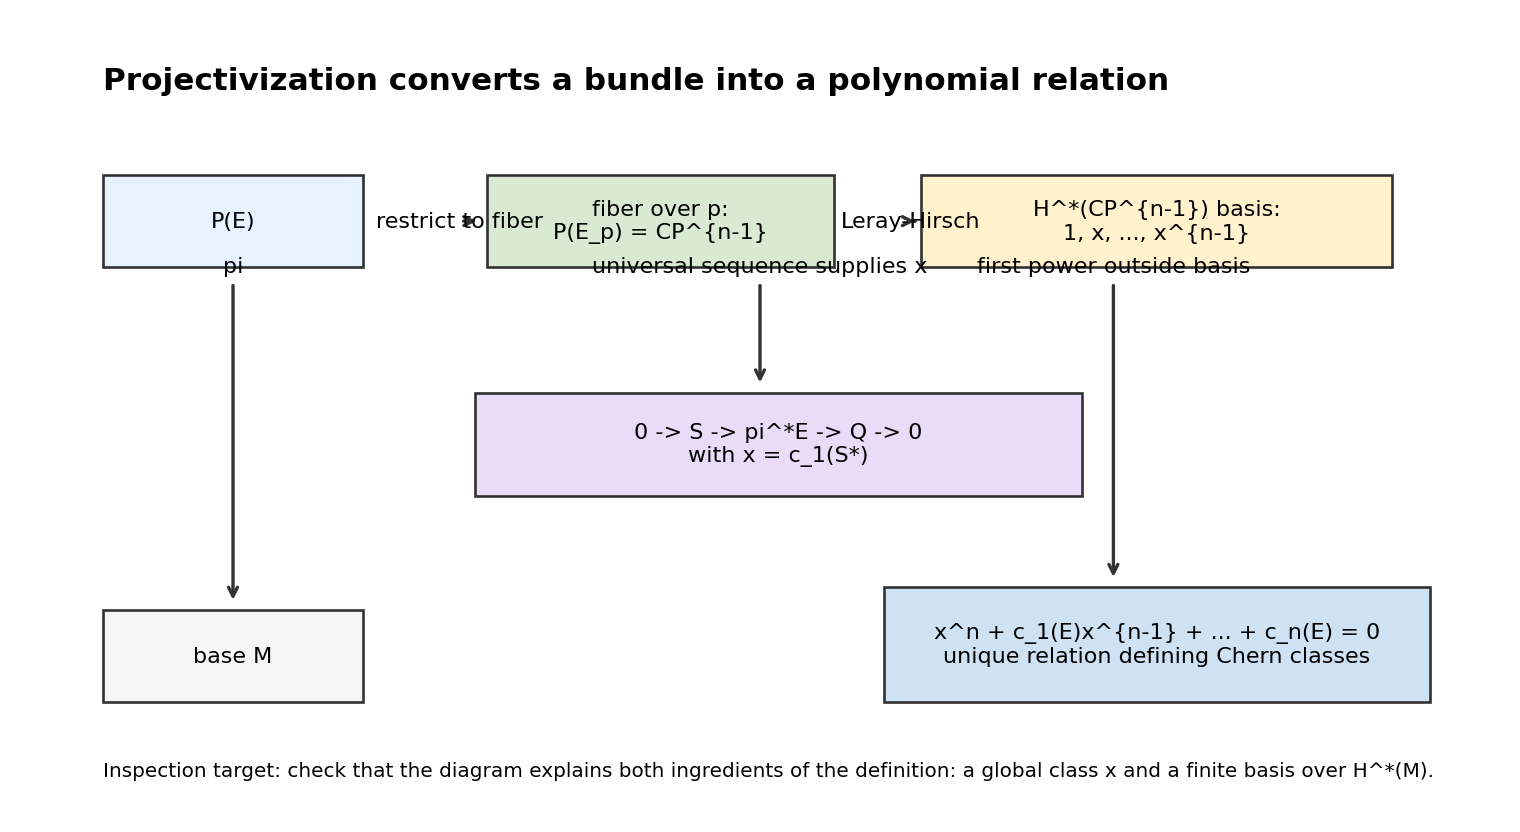

In [4]:
def draw_box(ax, xy, width, height, text, fc="#ffffff", ec="#333333", fontsize=10):
    x0, y0 = xy
    rect = plt.Rectangle((x0, y0), width, height, facecolor=fc, edgecolor=ec, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x0 + width / 2, y0 + height / 2, text, ha="center", va="center", fontsize=fontsize, wrap=True)

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

draw_box(ax, (0.7, 1.0), 2.1, 0.8, "base M", fc="#f6f6f6")
draw_box(ax, (0.7, 4.8), 2.1, 0.8, "P(E)", fc="#e6f2ff")
draw_box(ax, (3.8, 4.8), 2.8, 0.8, "fiber over p:\nP(E_p) = CP^{n-1}", fc="#d9ead3")
draw_box(ax, (7.3, 4.8), 3.8, 0.8, "H^*(CP^{n-1}) basis:\n1, x, ..., x^{n-1}", fc="#fff2cc")
draw_box(ax, (3.7, 2.8), 4.9, 0.9, "0 -> S -> pi^*E -> Q -> 0\nwith x = c_1(S*)", fc="#eadcf8")
draw_box(ax, (7.0, 1.0), 4.4, 1.0, "x^n + c_1(E)x^{n-1} + ... + c_n(E) = 0\nunique relation defining Chern classes", fc="#cfe2f3")

arrowprops = dict(arrowstyle="->", lw=1.5, color="#333333")
ax.annotate("pi", xy=(1.75, 1.85), xytext=(1.75, 4.75), arrowprops=arrowprops, ha="center")
ax.annotate("restrict to fiber", xy=(3.75, 5.2), xytext=(2.9, 5.2), arrowprops=arrowprops, va="center")
ax.annotate("Leray-Hirsch", xy=(7.25, 5.2), xytext=(6.65, 5.2), arrowprops=arrowprops, va="center")
ax.annotate("first power outside basis", xy=(8.85, 2.05), xytext=(8.85, 4.75), arrowprops=arrowprops, ha="center")
ax.annotate("universal sequence supplies x", xy=(6.0, 3.75), xytext=(6.0, 4.75), arrowprops=arrowprops, ha="center")

ax.text(0.7, 6.35, "Projectivization converts a bundle into a polynomial relation", fontsize=14, weight="bold")
ax.text(0.7, 0.35, "Inspection target: check that the diagram explains both ingredients of the definition: a global class x and a finite basis over H^*(M).", fontsize=9)
projectivization_path = save_matplotlib(fig, FIGURES / "chern-projectivization-relation.png")
plt.close(fig)

rank = 4
basis = [f"x^{k}" if k > 1 else ("x" if k == 1 else "1") for k in range(rank)]
projectivization_check_path = save_json(
    {
        "rank_example": rank,
        "leray_hirsch_basis": basis,
        "basis_length_equals_rank": len(basis) == rank,
        "relation_term_count": rank + 1,
        "relation": "x^n + c1*x^(n-1) + ... + cn = 0",
    },
    CHECKS / "projectivization-relation.json",
)
display_artifact(projectivization_path, width=920)


## Exact Polynomial Checks For Chern Roots

The splitting principle lets us pretend, for polynomial identities, that a rank `n` bundle has line-bundle summands with roots `x_1, ..., x_n`. Then

```text
c(E) = product_i (1 + x_i),
```

and every Chern-class calculation is a symmetric-polynomial calculation. The checks below are exact symbolic checks, not numerical samples.


In [5]:
a, b, c, y, z, x = sp.symbols("a b c y z x")
roots_E3 = [a, b, c]
roots_E2 = [a, b]
roots_F2 = [y, z]

def total_class(roots):
    expr = sp.Integer(1)
    for root in roots:
        expr *= 1 + root
    return sp.expand(expr)

def elementary(roots, k):
    if k == 0:
        return sp.Integer(1)
    return sp.expand(sum(sp.prod(combo) for combo in itertools.combinations(roots, k)))

c1_E3, c2_E3, c3_E3 = [elementary(roots_E3, k) for k in range(1, 4)]
projectivization_relation = sp.expand(x**3 + c1_E3 * x**2 + c2_E3 * x + c3_E3)
root_relation = sp.expand(sp.prod(x + root for root in roots_E3))

whitney_lhs = total_class(roots_E2 + roots_F2)
whitney_rhs = sp.expand(total_class(roots_E2) * total_class(roots_F2))

dual_total = total_class([-r for r in roots_E3])
dual_expected = sp.expand(1 - c1_E3 + c2_E3 - c3_E3)

tensor_line_lhs = total_class([r + y for r in roots_E3])
tensor_line_rhs = sp.expand(sum(elementary(roots_E3, i) * (1 + y) ** (3 - i) for i in range(4)))

exterior_square_lhs = total_class([a + b, a + c, b + c])
exterior_square_source_style = sp.expand((1 + c1_E3) ** 3 - c1_E3 * (1 + c1_E3) ** 2 + c2_E3 * (1 + c1_E3) - c3_E3)

top_chern_with_zero_root = elementary([a, b, 0], 3)

identity_rows = [
    {
        "identity": "projectivization relation after splitting",
        "left": str(projectivization_relation),
        "right": str(root_relation),
        "residual": str(sp.simplify(projectivization_relation - root_relation)),
    },
    {
        "identity": "Whitney product formula for E plus F",
        "left": str(whitney_lhs),
        "right": str(whitney_rhs),
        "residual": str(sp.simplify(whitney_lhs - whitney_rhs)),
    },
    {
        "identity": "dual bundle signs",
        "left": str(dual_total),
        "right": str(dual_expected),
        "residual": str(sp.simplify(dual_total - dual_expected)),
    },
    {
        "identity": "tensor by a line bundle",
        "left": str(tensor_line_lhs),
        "right": str(tensor_line_rhs),
        "residual": str(sp.simplify(tensor_line_lhs - tensor_line_rhs)),
    },
    {
        "identity": "exterior square of a rank 3 bundle",
        "left": str(exterior_square_lhs),
        "right": str(exterior_square_source_style),
        "residual": str(sp.simplify(exterior_square_lhs - exterior_square_source_style)),
    },
    {
        "identity": "top Chern vanishes when one split summand has root 0",
        "left": str(top_chern_with_zero_root),
        "right": "0",
        "residual": str(top_chern_with_zero_root),
    },
]
identity_table_path = save_csv(identity_rows, TABLES / "chern-root-identity-ledger.csv")

symbolic_checks = {
    row["identity"]: sp.simplify(sp.sympify(row["residual"])) == 0 for row in identity_rows
}
symbolic_check_path = save_json(
    {
        "chern_roots_rank_3": [str(root) for root in roots_E3],
        "c1": str(c1_E3),
        "c2": str(c2_E3),
        "c3": str(c3_E3),
        "checks": {key: bool(value) for key, value in symbolic_checks.items()},
    },
    CHECKS / "symbolic-polynomial-checks.json",
)
display(pd.DataFrame(identity_rows)[["identity", "residual"]])
assert all(symbolic_checks.values())


,identity,residual
0,projectivization relation after splitting,0
1,Whitney product formula for E plus F,0
2,dual bundle signs,0
3,tensor by a line bundle,0
4,exterior square of a rank 3 bundle,0
5,top Chern vanishes when one split summand has ...,0


## Splitting Principle As A Flag-Tower Diagram

The splitting principle is not a claim that `E` already splits over `M`. It says we may pull back to a larger manifold where it splits, and the pullback on cohomology is injective. That is why a polynomial identity proved after splitting is still true before splitting.

For a rank `4` bundle the flag construction is a tower:

```text
F(E) = P(Q_2) -> P(Q_1) -> P(E) -> M.
```

At the top, the pulled-back bundle has four line-bundle roots. The monomial basis has `4 * 3 * 2 * 1 = 24` elements, matching the Poincare-count pattern for the complete flag fiber.


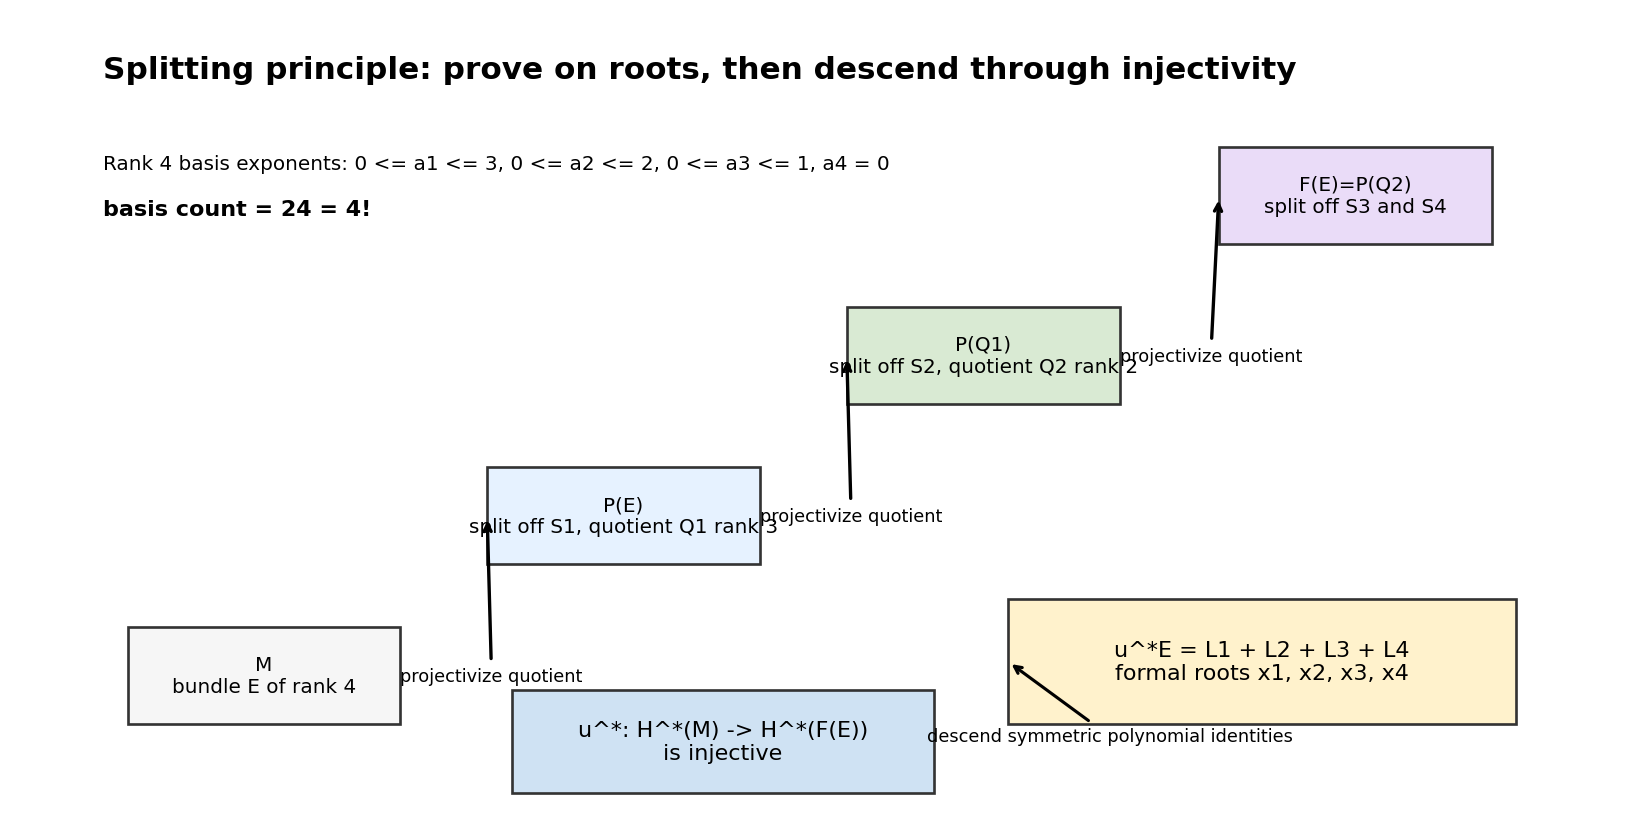

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")

levels = [
    ("M", "bundle E of rank 4", 0.9, 0.8, "#f6f6f6"),
    ("P(E)", "split off S1, quotient Q1 rank 3", 3.8, 2.2, "#e6f2ff"),
    ("P(Q1)", "split off S2, quotient Q2 rank 2", 6.7, 3.6, "#d9ead3"),
    ("F(E)=P(Q2)", "split off S3 and S4", 9.7, 5.0, "#eadcf8"),
]
for title, subtitle, x0, y0, color in levels:
    draw_box(ax, (x0, y0), 2.2, 0.85, f"{title}\n{subtitle}", fc=color, fontsize=9)
for i in range(len(levels) - 1):
    _, _, x0, y0, _ = levels[i]
    _, _, x1, y1, _ = levels[i + 1]
    ax.annotate("projectivize quotient", xy=(x1, y1 + 0.42), xytext=(x0 + 2.2, y0 + 0.42), arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=8, va="center")

draw_box(ax, (8.0, 0.8), 4.1, 1.1, "u^*E = L1 + L2 + L3 + L4\nformal roots x1, x2, x3, x4", fc="#fff2cc", fontsize=10)
draw_box(ax, (4.0, 0.2), 3.4, 0.9, "u^*: H^*(M) -> H^*(F(E))\nis injective", fc="#cfe2f3", fontsize=10)
ax.annotate("descend symmetric polynomial identities", xy=(8.0, 1.35), xytext=(7.35, 0.65), arrowprops=dict(arrowstyle="->", lw=1.4), fontsize=8)

basis_exponents = list(itertools.product(range(4), range(3), range(2), range(1)))
ax.text(0.7, 6.45, "Splitting principle: prove on roots, then descend through injectivity", fontsize=14, weight="bold")
ax.text(0.7, 5.65, "Rank 4 basis exponents: 0 <= a1 <= 3, 0 <= a2 <= 2, 0 <= a3 <= 1, a4 = 0", fontsize=9)
ax.text(0.7, 5.25, f"basis count = {len(basis_exponents)} = 4!", fontsize=10, weight="bold")

splitting_path = save_matplotlib(fig, FIGURES / "splitting-principle-flag-tower.png")
plt.close(fig)

t = sp.symbols("t")
poincare_flag_rank4 = sp.expand(sp.prod(sum(t ** (2 * j) for j in range(k)) for k in range(1, 5)))
splitting_check_path = save_json(
    {
        "rank": 4,
        "basis_count": len(basis_exponents),
        "factorial_check": len(basis_exponents) == 24,
        "poincare_polynomial_rank_4_flag": str(poincare_flag_rank4),
        "sample_basis_exponents": basis_exponents[:8],
    },
    CHECKS / "splitting-principle-flag-tower.json",
)
display_artifact(splitting_path, width=960)


## Pontrjagin Classes: Real Bundles Viewed Through Complexification

The source span begins Section 22 by comparing a complex vector space with its conjugate, then comparing realization and complexification. The useful computational image is this: after complexification, real geometry contributes roots in conjugate pairs. A real oriented `2`-plane that behaves like a complex line with root `u` contributes roots `u` and `-u` after complexification.

For a real rank `4` bundle with formal paired roots `u, -u, v, -v`, the total Chern class of the complexification is

```text
(1 + u)(1 - u)(1 + v)(1 - v).
```

The odd Chern classes cancel. The surviving even data gives the usual Pontrjagin classes up to the standard sign convention: `p_i(V) = (-1)^i c_{2i}(V_C)`.

This is also where the Euler and Stiefel-Whitney context belongs. Euler is an oriented top-degree class. Stiefel-Whitney classes are real-bundle classes with mod-2 coefficients, so they are not computed in this de Rham notebook; they are included as the neighboring real characteristic-class family that does not require orientation.


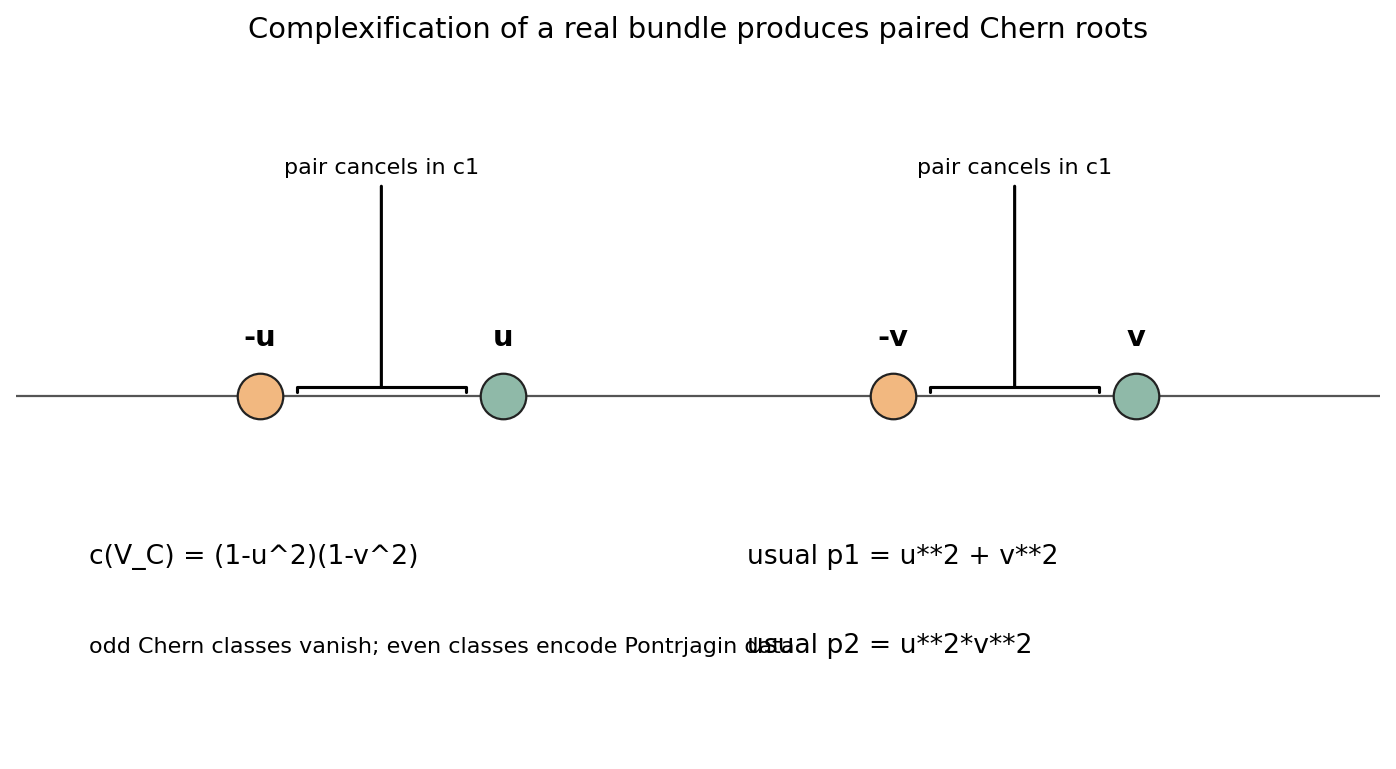

,family,bundle_type,coefficients,orientation_needed,notebook_role
0,Stiefel-Whitney,real,mod 2,no,context only; outside de Rham coefficient system
1,Euler,oriented real rank n,"de Rham or integral, depending on setup",yes,compared with top Chern class and line-bundle c1
2,Chern,complex,de Rham in this notebook,complex orientation supplies one,main class family defined through projectiviza...
3,Pontrjagin,real,"de Rham here, integral with care elsewhere",no for definition; orientation matters in appl...,computed from Chern classes of the complexific...


In [7]:
u, v = sp.symbols("u v")
paired_roots = [u, -u, v, -v]
complexified_total = sp.expand(total_class(paired_roots))
paired_coeffs = [elementary(paired_roots, k) for k in range(1, 5)]
usual_p1 = sp.expand(-paired_coeffs[1])
usual_p2 = sp.expand(paired_coeffs[3])

fig, ax = plt.subplots(figsize=(11, 5.7))
ax.axhline(0, color="#555555", lw=1)
positions = [-1.8, -0.8, 0.8, 1.8]
labels = ["-u", "u", "-v", "v"]
colors = ["#f2b880", "#8fb9a8", "#f2b880", "#8fb9a8"]
for px, label, color in zip(positions, labels, colors):
    ax.scatter(px, 0, s=420, color=color, edgecolor="#222222", zorder=3)
    ax.text(px, 0.2, label, ha="center", va="bottom", fontsize=13, weight="bold")
ax.annotate("pair cancels in c1", xy=(-1.3, 0.02), xytext=(-1.3, 1.0), ha="center", arrowprops=dict(arrowstyle="-[,widthB=3.8", lw=1.4))
ax.annotate("pair cancels in c1", xy=(1.3, 0.02), xytext=(1.3, 1.0), ha="center", arrowprops=dict(arrowstyle="-[,widthB=3.8", lw=1.4))
ax.text(-2.5, -0.75, "c(V_C) = (1-u^2)(1-v^2)", fontsize=12)
ax.text(-2.5, -1.15, "odd Chern classes vanish; even classes encode Pontrjagin data", fontsize=10)
ax.text(0.2, -0.75, f"usual p1 = {sp.sstr(usual_p1)}", fontsize=12)
ax.text(0.2, -1.15, f"usual p2 = {sp.sstr(usual_p2)}", fontsize=12)
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-1.6, 1.55)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Complexification of a real bundle produces paired Chern roots")
for spine in ax.spines.values():
    spine.set_visible(False)
pontrjagin_path = save_matplotlib(fig, FIGURES / "pontrjagin-complexification-roots.png")
plt.close(fig)

class_family_rows = [
    {
        "family": "Stiefel-Whitney",
        "bundle_type": "real",
        "coefficients": "mod 2",
        "orientation_needed": "no",
        "notebook_role": "context only; outside de Rham coefficient system",
    },
    {
        "family": "Euler",
        "bundle_type": "oriented real rank n",
        "coefficients": "de Rham or integral, depending on setup",
        "orientation_needed": "yes",
        "notebook_role": "compared with top Chern class and line-bundle c1",
    },
    {
        "family": "Chern",
        "bundle_type": "complex",
        "coefficients": "de Rham in this notebook",
        "orientation_needed": "complex orientation supplies one",
        "notebook_role": "main class family defined through projectivization",
    },
    {
        "family": "Pontrjagin",
        "bundle_type": "real",
        "coefficients": "de Rham here, integral with care elsewhere",
        "orientation_needed": "no for definition; orientation matters in applications",
        "notebook_role": "computed from Chern classes of the complexification",
    },
]
class_family_path = save_csv(class_family_rows, TABLES / "real-complex-class-family-context.csv")
pontrjagin_check_path = save_json(
    {
        "paired_roots": [str(root) for root in paired_roots],
        "total_chern_of_complexification": str(complexified_total),
        "chern_coefficients_c1_to_c4": [str(coeff) for coeff in paired_coeffs],
        "odd_chern_vanish": bool(paired_coeffs[0] == 0 and paired_coeffs[2] == 0),
        "usual_p1": str(usual_p1),
        "usual_p2": str(usual_p2),
        "usual_sign_convention": "p_i(V) = (-1)^i c_{2i}(V_C)",
    },
    CHECKS / "pontrjagin-complexification-roots.json",
)
display_artifact(pontrjagin_path, width=880)
display(pd.DataFrame(class_family_rows))
assert paired_coeffs[0] == 0 and paired_coeffs[2] == 0


## Applied Lab: Move One Root, Watch The Classes

In the split world, changing a line-bundle summand changes a root. The Plotly artifact below fixes two roots and moves the third. The curves show the three Chern coefficients of a rank `3` bundle:

```text
c_1 = x_1 + x_2 + x_3,
c_2 = x_1x_2 + x_1x_3 + x_2x_3,
c_3 = x_1x_2x_3.
```

Inspection tasks:

1. Find the sample where the moving root is `0`; the top Chern class vanishes there, matching the principle that a split summand with a nowhere-zero section kills the top product.
2. Compare `c_1` and `c_2`: one changes with slope `1`, while the other changes with slope equal to the sum of the fixed roots.
3. Replace the fixed roots in the next cell and rerun. The formulas remain symmetric, but the visible slopes and zeroes change.


In [8]:
fixed_roots = (1.2, -0.55)
moving = np.linspace(-2.5, 2.5, 201)
c1_values = fixed_roots[0] + fixed_roots[1] + moving
c2_values = fixed_roots[0] * fixed_roots[1] + (fixed_roots[0] + fixed_roots[1]) * moving
c3_values = fixed_roots[0] * fixed_roots[1] * moving

fig = go.Figure()
fig.add_trace(go.Scatter(x=moving, y=c1_values, mode="lines", name="c1"))
fig.add_trace(go.Scatter(x=moving, y=c2_values, mode="lines", name="c2"))
fig.add_trace(go.Scatter(x=moving, y=c3_values, mode="lines", name="c3"))
fig.add_vline(x=0, line_dash="dash", line_color="#444444", annotation_text="moving root = 0")
fig.update_layout(
    title="Chern-root coefficient lab for E = L_a + L_b + L_r",
    xaxis_title="moving root r",
    yaxis_title="coefficient value",
    template="plotly_white",
    width=850,
    height=520,
)
lab_html_path = HTML / "chern-root-polynomial-lab.html"
fig.write_html(str(lab_html_path), include_plotlyjs=True, full_html=True)

zero_index = int(np.argmin(np.abs(moving)))
lab_check = {
    "fixed_roots": list(fixed_roots),
    "moving_root_at_zero_sample": float(moving[zero_index]),
    "c1_at_zero": float(c1_values[zero_index]),
    "c2_at_zero": float(c2_values[zero_index]),
    "c3_at_zero": float(c3_values[zero_index]),
    "top_chern_zero_at_zero_root": abs(float(c3_values[zero_index])) < 1e-12,
    "c1_slope_expected": 1.0,
    "c2_slope_expected": float(sum(fixed_roots)),
    "c3_slope_expected": float(fixed_roots[0] * fixed_roots[1]),
}
lab_check_path = save_json(lab_check, CHECKS / "chern-root-polynomial-lab.json")
display_artifact(lab_html_path, width=900, height=560)
print(json.dumps(lab_check, indent=2))
assert lab_check["top_chern_zero_at_zero_root"]


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{
  "fixed_roots": [
    1.2,
    -0.55
  ],
  "moving_root_at_zero_sample": 0.0,
  "c1_at_zero": 0.6499999999999999,
  "c2_at_zero": -0.66,
  "c3_at_zero": -0.0,
  "top_chern_zero_at_zero_root": true,
  "c1_slope_expected": 1.0,
  "c2_slope_expected": 0.6499999999999999,
  "c3_slope_expected": -0.66
}


## Takeaways

- Chern classes in this chapter are not introduced by curvature forms first; they are defined by the cohomology ring of `P(E)` and the tautological line bundle over it.
- The splitting principle is a proof transport device. It replaces a hard bundle by a pulled-back split bundle, checks symmetric polynomial identities on roots, then descends the result through injectivity.
- The Whitney product formula, dual signs, tensor-by-line formulas, exterior-power formulas, and top-Chern/Euler comparison all become exact polynomial checks after splitting.
- Pontrjagin classes are the real-bundle continuation of the story: complexify the real bundle, observe conjugate root-pair cancellation, and keep the even Chern data with the usual sign convention.
- Stiefel-Whitney classes are part of the chapter's real characteristic-class landscape, but their natural coefficient system is mod 2, so this de Rham notebook marks their role rather than pretending to compute them here.


In [9]:
# final_sanity
new_artifact_paths = [
    source_span_path,
    routing_path,
    route_path,
    route_check_path,
    projectivization_path,
    projectivization_check_path,
    identity_table_path,
    symbolic_check_path,
    splitting_path,
    splitting_check_path,
    pontrjagin_path,
    pontrjagin_check_path,
    class_family_path,
    lab_html_path,
    lab_check_path,
]
assert_artifacts(new_artifact_paths, min_bytes=80)

png_paths = [route_path, projectivization_path, splitting_path, pontrjagin_path]
image_stats = {}
for path in png_paths:
    with Image.open(path) as image:
        stat = ImageStat.Stat(image.convert("RGB"))
        image_stats[path.name] = {
            "size": image.size,
            "max_channel_stddev": max(stat.stddev),
            "bytes": path.stat().st_size,
        }
    assert image_stats[path.name]["size"][0] >= 64 and image_stats[path.name]["size"][1] >= 64
    assert image_stats[path.name]["max_channel_stddev"] > 1.0

assert nx.is_weakly_connected(G)
assert all(bool(value) for value in symbolic_checks.values())
assert len(basis_exponents) == 24
assert paired_coeffs[0] == 0 and paired_coeffs[2] == 0
assert lab_check["top_chern_zero_at_zero_root"]

final_report = {
    "unit": UNIT_KEY,
    "source_span": source_span,
    "artifact_count": len(new_artifact_paths),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in new_artifact_paths],
    "image_stats": image_stats,
    "checks": {
        "route_graph_weakly_connected": nx.is_weakly_connected(G),
        "symbolic_checks_all_pass": all(bool(value) for value in symbolic_checks.values()),
        "flag_basis_count_rank4_is_24": len(basis_exponents) == 24,
        "pontrjagin_odd_chern_cancel": paired_coeffs[0] == 0 and paired_coeffs[2] == 0,
        "lab_top_chern_zero_at_zero_root": lab_check["top_chern_zero_at_zero_root"],
    },
}
final_sanity_path = save_json(final_report, CHECKS / "final-sanity.json")
assert_artifacts([final_sanity_path], min_bytes=80)
print(json.dumps(final_report["checks"], indent=2))
print(f"final_sanity passed with {len(new_artifact_paths) + 1} generated artifacts/check files")


{
  "route_graph_weakly_connected": true,
  "symbolic_checks_all_pass": true,
  "flag_basis_count_rank4_is_24": true,
  "pontrjagin_odd_chern_cancel": true,
  "lab_top_chern_zero_at_zero_root": true
}
final_sanity passed with 16 generated artifacts/check files
